In [5]:
# Install kagglehub
!pip install kagglehub -q

In [6]:
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset downloaded to: /kaggle/input/creditcardfraud


## Load the data and check basic stats

We're using the classic Kaggle Credit Card Fraud Detection dataset. It contains 284,807 transactions, of which only 492 (0.17%) are fraudulent. No missing values. The `Amount` and `Time` columns are the only unscaled ones – the rest are PCA components.

In [12]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (already in df)
# If not, run the direct download from previous step

df = pd.read_csv(os.path.join(path, "creditcard.csv"))
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum())  # Should be 0
print("\nClass distribution:\n", df['Class'].value_counts())
print("Fraud percentage: {:.4f}%".format(df['Class'].mean() * 100))

Dataset shape: (284807, 31)

Missing values:
 0

Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64
Fraud percentage: 0.1727%


In [10]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


## Split data while preserving fraud ratio

If we split randomly, the test set might end up with almost no fraud cases. Stratified splitting keeps the same 0.17% fraud rate in both training and test sets. We'll also fix the random seed so the split is reproducible.

In [13]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train fraud rate: {y_train.mean():.6f}")
print(f"Test fraud rate:  {y_test.mean():.6f}")

Train fraud rate: 0.001729
Test fraud rate:  0.001720


## Train a logistic regression model

Logistic regression is a fast, interpretable baseline. Because the data is heavily imbalanced, we use `class_weight='balanced'` – this tells the model to pay more attention to the rare fraud cases.

We also scale `Amount` and `Time` (the PCA features are already scaled). The performance metrics we care about are **precision** and **recall** for the fraud class, not overall accuracy.

In [14]:
# Scale only amount and time – PCA features already scaled
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test_scaled[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

lr = LogisticRegression(class_weight='balanced', random_state=42, C=0.1)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9720


## Train a Random Forest classifier

Random forest can capture non‑linear patterns without scaling the features. Again we use `class_weight='balanced'` to handle the imbalance. It usually gives better precision than logistic regression, but may overfit if we don't tune it.

In [15]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9529


## Adjust the decision threshold

By default, a model predicts "fraud" if the probability > 0.5. But for fraud detection, we might want to catch more fraud (increase recall) even if that means more false alarms (lower precision). Here we search for a threshold that keeps precision above 70% – a reasonable target for a real fintech system. The result shows the recall we can expect at that threshold.

In [16]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

# Find threshold where precision >= 0.7
idx = np.where(precisions >= 0.7)[0]
if len(idx) > 0:
    best_thresh = thresholds[idx[0]]
    print(f"Threshold to achieve precision >=70%: {best_thresh:.4f}")
    print(f"  Expected recall at that threshold: {recalls[idx[0]]:.4f}")
else:
    print("Cannot achieve precision >=70% with this model.")

Threshold to achieve precision >=70%: 0.0800
  Expected recall at that threshold: 0.8878


## Evaluate the final tuned model

We apply the new threshold and plot the confusion matrix. The numbers tell us: how many frauds we caught (true positives), how many we missed (false negatives), and how many legitimate customers were wrongly flagged (false positives). This allows a business to choose the right trade‑off between catching fraud and annoying customers.

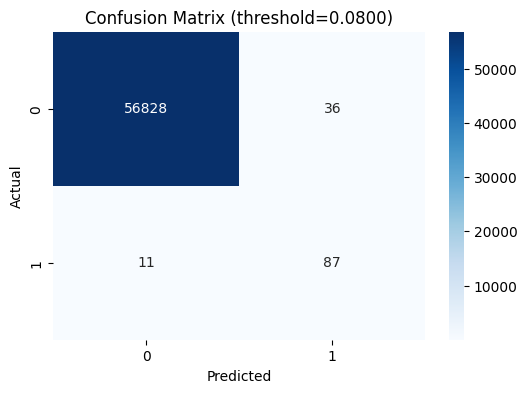

Precision at threshold: 0.7073
Recall at threshold:    0.8878


In [17]:
from sklearn.metrics import confusion_matrix

# Use the chosen threshold
y_pred_tuned = (y_proba_rf >= best_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (threshold={best_thresh:.4f})')
plt.show()

print(f"Precision at threshold: {precisions[idx[0]]:.4f}")
print(f"Recall at threshold:    {recalls[idx[0]]:.4f}")